In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("delivery_time.csv")

In [3]:
print(df.head())
print(df.info())
print(df.describe())


   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  N

In [4]:
df = df.dropna()

In [5]:
if 'ID' in df.columns:
    df = df.drop('ID', axis=1)



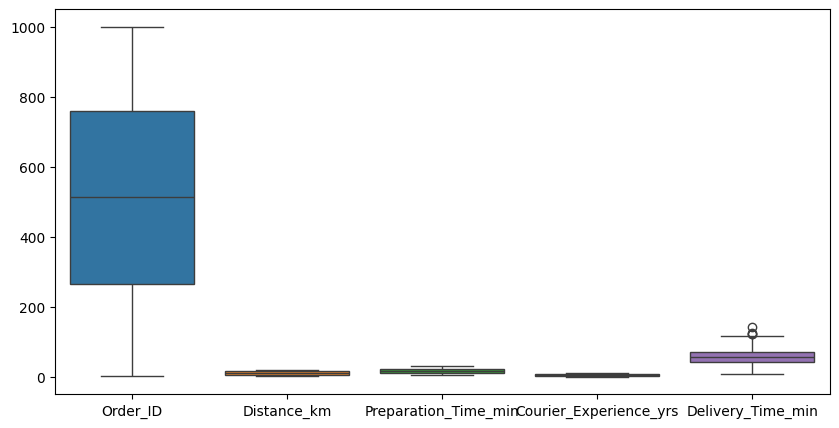

In [6]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df)
plt.show()

In [8]:
df_numeric = df.select_dtypes(include=[np.number])

Q1 = df_numeric.quantile(0.25)
Q3 = df_numeric.quantile(0.75)
IQR = Q3 - Q1

filter = ~((df_numeric < (Q1 - 1.5 * IQR)) | 
           (df_numeric > (Q3 + 1.5 * IQR))).any(axis=1)

df = df[filter]

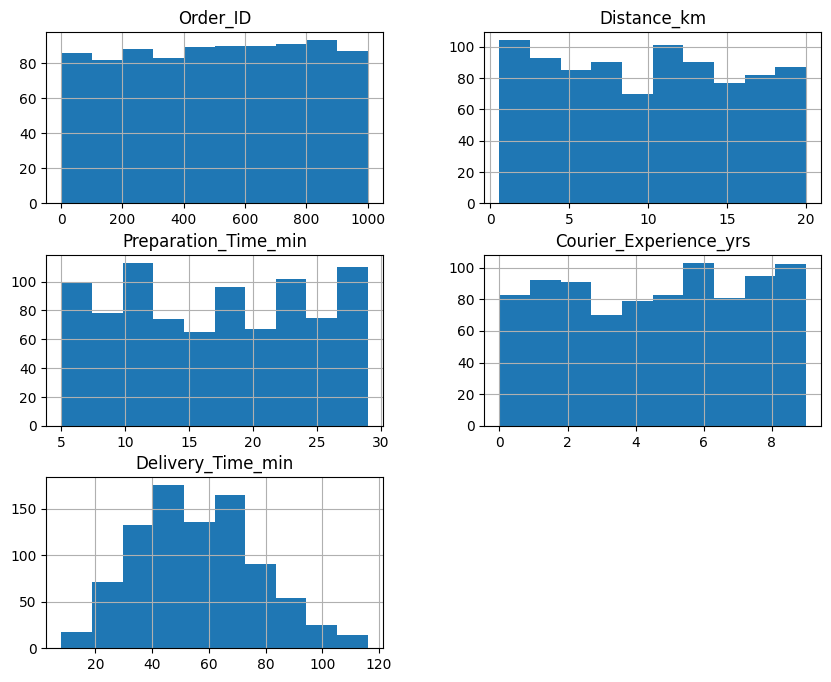

In [9]:
df.hist(figsize=(10,8))
plt.show()

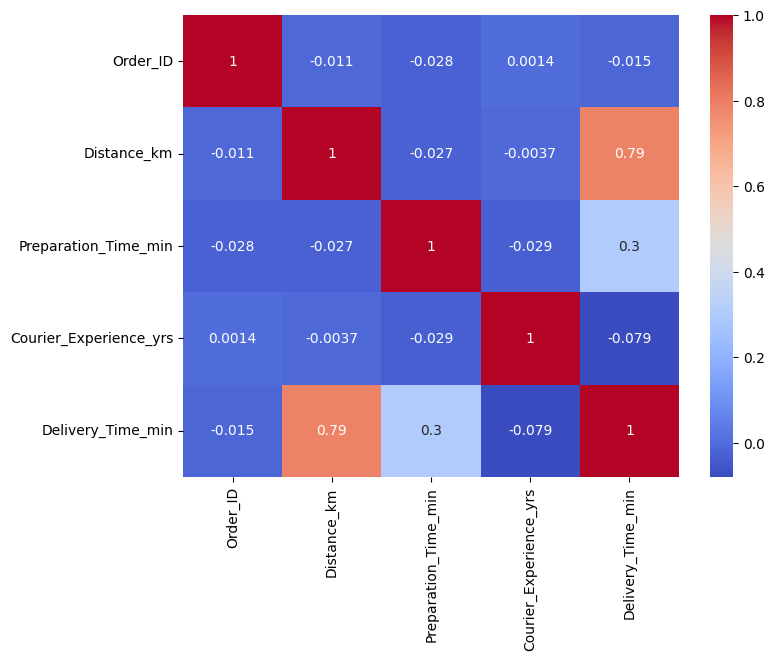

In [11]:
df_numeric = df.select_dtypes(include=['number'])

plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap='coolwarm')
plt.show()

In [15]:
# Fix column names
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")



# Select target safely
target_column = df.columns[-1]

# Split features and target
X = df.drop(target_column, axis=1)
y = df[target_column]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [17]:
# Encode categorical columns
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in X.columns:
    if X[col].dtype == 'object':
        X[col] = le.fit_transform(X[col])

# Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Train model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully ✅")


Model trained successfully ✅


In [18]:
# 12. Prediction
y_pred = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MSE: 114.6601929939981
R2 Score: 0.7547692561548698


In [21]:
new_data = X.iloc[[0]]   # take sample row

prediction = model.predict(new_data)

print("Predicted Delivery Time:", prediction)

Predicted Delivery Time: [51.58623872]


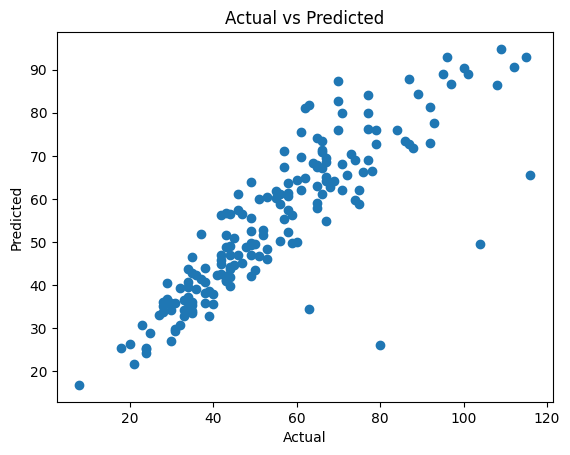

In [22]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()